Top 10 Highly Correlated Pairs:
coord_mean        Nt                 1.000000
coord_std         connectivity       0.964497
Deff_x            porosity           0.955490
coord_mean        coord_std          0.953349
coord_std         Nt                 0.953339
connectivity      Nt                 0.949969
coord_mean        connectivity       0.949966
Kx                Deff_x             0.935678
                  porosity           0.856406
throat_diam_mean  throat_diam_std    0.806158
dtype: float64
Total variance explained by first 2 PCs: 75.59%
Total variance explained by first 3 PCs: 87.66%
Total variance explained by first 4 PCs: 97.22%

Top Loadings for PC1 (Primary variance driver):
Deff_x        0.487864
porosity      0.475665
Kx            0.436331
coord_mean    0.327570
coord_std     0.326299
Np            0.144936
tau_x        -0.332516
Name: PC1, dtype: float64


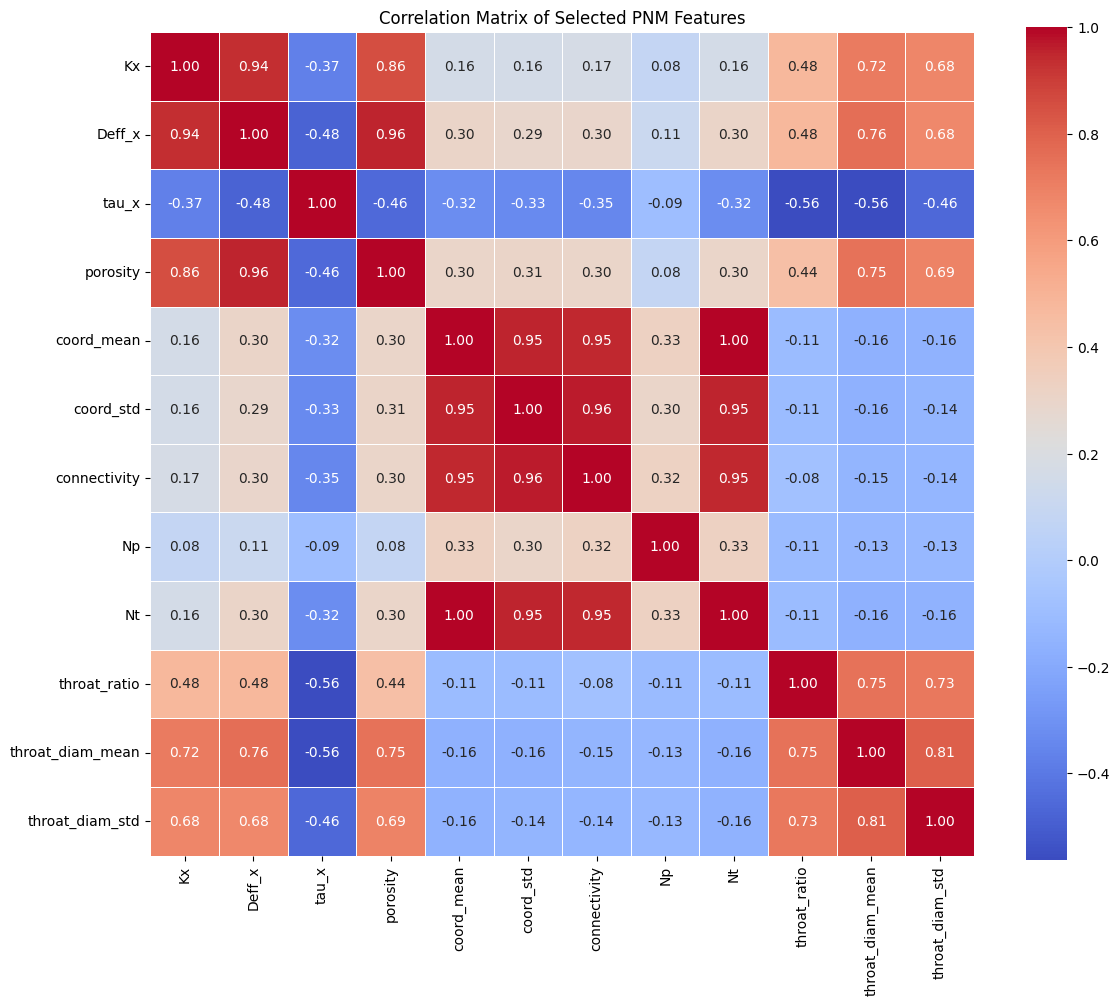

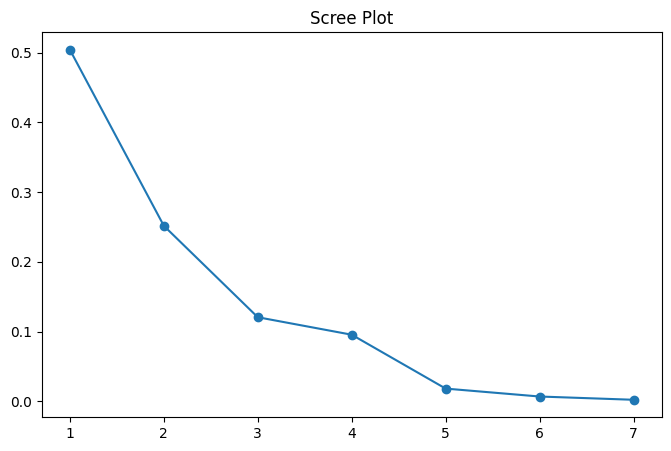

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
# Load the dataset
df = pd.read_excel('pnm_dataset_all_versions.xlsx',sheet_name = 'clean_285')

#first check the dataset
#print(df.info())
selected_features = [
    'Kx', 'Deff_x', 'tau_x',              # Transport properties
    'porosity',                           # Bulk property
    'coord_mean', 'coord_std', 'connectivity',           # Topology/Connectivity
    'Np', 'Nt',                            # Node/Throat counts
    'throat_ratio',                       # Geometric ratio
    'throat_diam_mean', 'throat_diam_std' # Throat geometry
]

X = df[selected_features]

# target y is weibull scale parameter and shape parameter
y_scale = df['pore_weibull_scale_input']
y_shape = df['pore_weibull_shape_input']


# check the covariance of variables
corr_matrix = X.corr()

# 2. Visualization using a Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)
plt.title('Correlation Matrix of Selected PNM Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

# Display highly correlated pairs
sol = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(ascending=False))

print("Top 10 Highly Correlated Pairs:")
print(sol.head(10))

'''
Top 10 Highly Correlated Pairs:
coord_mean        Nt                 1.000000
connectivity      coord_std          0.964497
Deff_x            porosity           0.955490
coord_mean        coord_std          0.953349
coord_std         Nt                 0.953339
connectivity      Nt                 0.949969
                  coord_mean         0.949966
Kx                Deff_x             0.935678
                  porosity           0.856406
throat_diam_mean  throat_diam_std    0.806158
'''

# Based on the correlation analysis, we can see that:
# - 'coord_mean' and 'Nt' are perfectly correlated (r=1.000), which means they provide the same information. We can keep one and drop the other.
# - 'connectivity' and 'coord_std' are highly correlated (r=0.964), so we can keep one of them as well.

# 1. Explicitly select the "Wanted" features for PCA
# These features describe the transport, topology, and geometry of the network.
selected_features = [
    'Kx', 'Deff_x', 'tau_x',              # Transport properties
    'porosity',                           # Bulk property
    'coord_mean', 'coord_std',            # Topology/Connectivity
    'Np',                                 # Node/Throat counts
]


# Create the feature matrix X
X = df[selected_features]

# 2. Scaling (Essential for PCA since units like Kx and porosity differ vastly)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA Analysis
pca = PCA(n_components=len(selected_features))
X_pca = pca.fit_transform(X_scaled)

# 4. Results Analysis
explained_var = pca.explained_variance_ratio_
print(f"Total variance explained by first 2 PCs: {sum(explained_var[:2]):.2%}")
print(f"Total variance explained by first 3 PCs: {sum(explained_var[:3]):.2%}")
print(f"Total variance explained by first 4 PCs: {sum(explained_var[:4]):.2%}")
# generate a scree plot to visualize the variance explained by each PC
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(selected_features) + 1), explained_var, marker='o')
plt.title('Scree Plot')

# 5. Loadings: View which variables contribute most to PC1
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(len(selected_features))], 
    index=selected_features
)
print("\nTop Loadings for PC1 (Primary variance driver):")
print(loadings['PC1'].sort_values(ascending=False))

# The top 2 principal components explained 80.5% of the variance, and the top 3 PCs explained 90.2% of the variance, which is a good indication that we can capture most of the information in the dataset with just a few components. The loadings for PC1 indicate that 'Kx', 'Deff_x', and 'tau_x' are the primary drivers of variance in the dataset, which makes sense given their importance in describing transport properties.

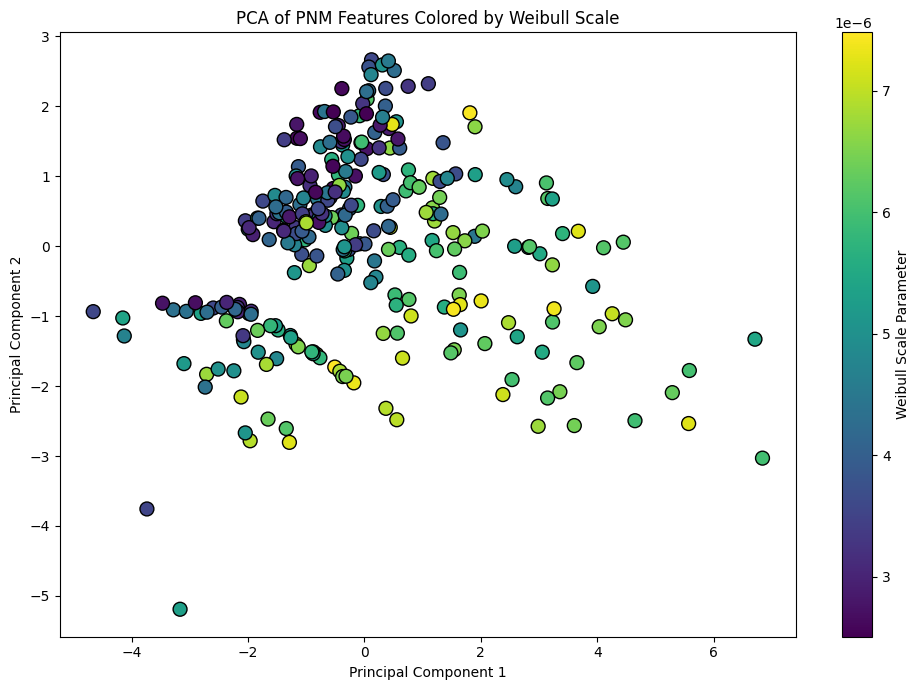

In [2]:
# 6. Visualization: PC1 and PC2 scatter plot colored by the target variable (weibull_scale)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_scale, cmap='viridis', edgecolor='k', s=100)
plt.colorbar(scatter, label='Weibull Scale Parameter')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of PNM Features Colored by Weibull Scale')
plt.tight_layout()
plt.savefig('pca_scatter_weibull_scale.png')

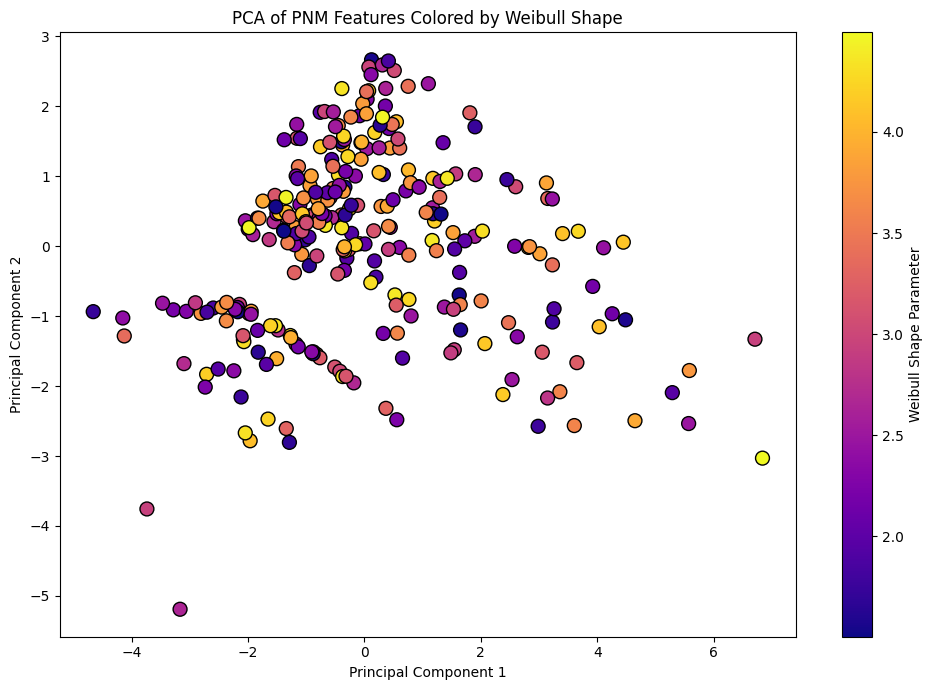

In [3]:
# 6. Visualization: PC1 vs PC2 colored by the target variable (weibull_shape)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_shape, cmap='plasma', edgecolor='k', s=100)
plt.colorbar(scatter, label='Weibull Shape Parameter')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of PNM Features Colored by Weibull Shape')
plt.tight_layout()
plt.savefig('pca_scatter_weibull_shape.png')
# from the scatter plots, we can visually inspect if there are any clusters or trends in the PCA space that correlate with the target variables (weibull scale and shape).
# We cannot see clear color gradients or clusters in the PCA space, which suggests that the relationship between the selected features and the target variables may be complex and not easily separable in just the first two principal components. 


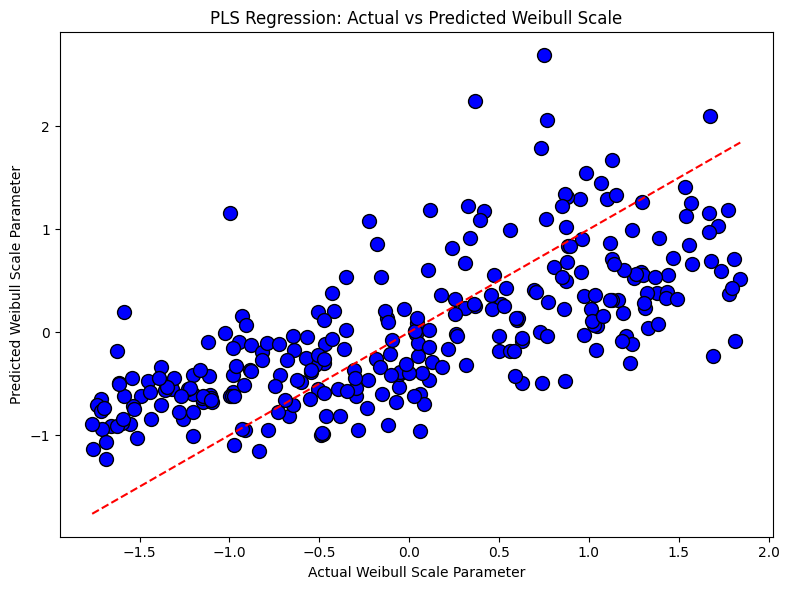

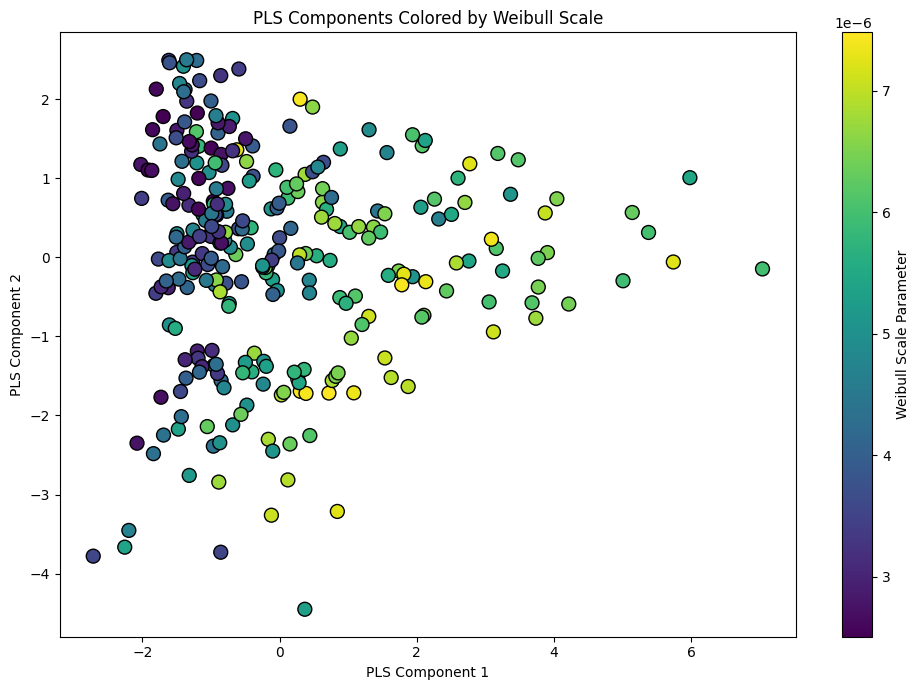

In [4]:
# Perform PLS regression to predict the target variable (weibull scale) using the PCA components as features
from sklearn.cross_decomposition import PLSRegression
Y = df[['pore_weibull_scale_input', 'pore_weibull_shape_input']]
scaler = StandardScaler()
Y_scaled = scaler.fit_transform(Y)
pls = PLSRegression(n_components=3)
pls.fit(X_scaled, Y_scaled)
Y_pred = pls.predict(X_scaled)
# visualize the predicted vs actual values for the weibull scale parameter
plt.figure(figsize=(8, 6))
plt.scatter(Y_scaled[:, 0], Y_pred[:, 0], color='blue', edgecolor='k', s=100)
plt.plot([Y_scaled[:, 0].min(), Y_scaled[:, 0].max()], [Y_scaled[:, 0].min(), Y_scaled[:, 0].max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual Weibull Scale Parameter')
plt.ylabel('Predicted Weibull Scale Parameter')
plt.title('PLS Regression: Actual vs Predicted Weibull Scale')
plt.tight_layout()
#visualize the first two PLS components colored by the target variable (weibull scale)
X_pls = pls.x_scores_
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pls[:, 0], X_pls[:, 1], c=y_scale, cmap='viridis', edgecolor='k', s=100)
plt.colorbar(scatter, label='Weibull Scale Parameter')
plt.xlabel('PLS Component 1')
plt.ylabel('PLS Component 2')
plt.title('PLS Components Colored by Weibull Scale')
plt.tight_layout()


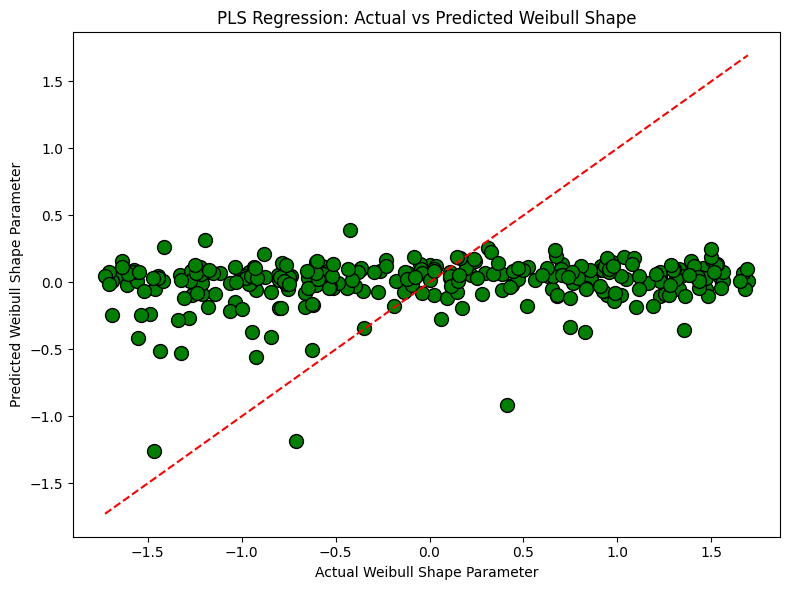

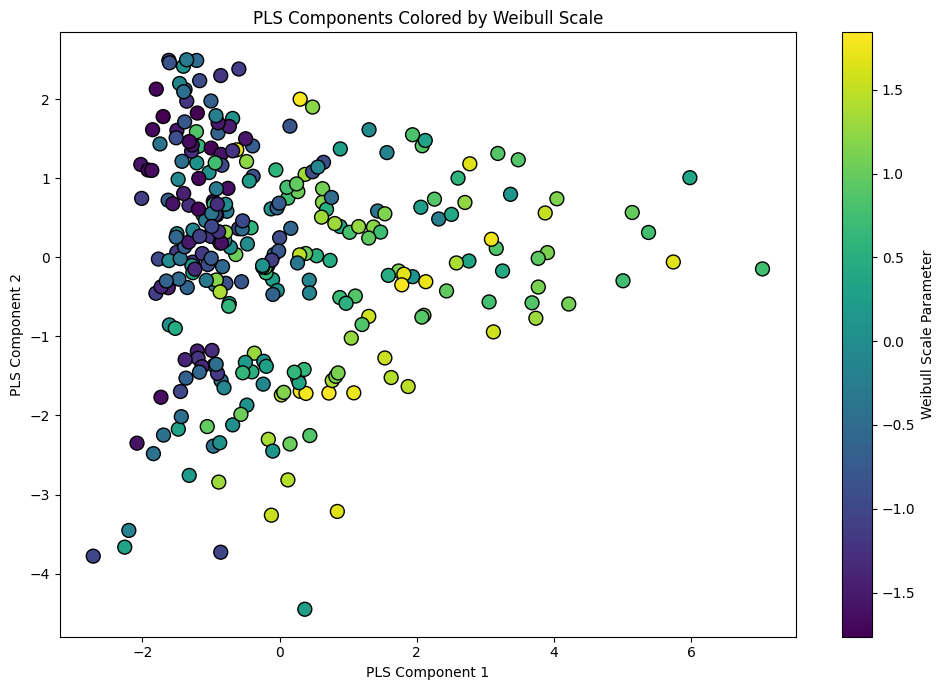

In [5]:
# visualize the predicted vs actual values for the weibull shape parameter
plt.figure(figsize=(8, 6))
plt.scatter(Y_scaled[:, 1], Y_pred[:, 1], color='green', edgecolor='k', s=100)
plt.plot([Y_scaled[:, 1].min(), Y_scaled[:, 1].max()], [Y_scaled[:, 1].min(), Y_scaled[:, 1].max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual Weibull Shape Parameter')
plt.ylabel('Predicted Weibull Shape Parameter')
plt.title('PLS Regression: Actual vs Predicted Weibull Shape')
plt.tight_layout()
# visualize the first two PLS components colored by the target variable (weibull scale)
X_pls = pls.x_scores_
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pls[:, 0], X_pls[:, 1], c=Y_scaled[:, 0], cmap='viridis', edgecolor='k', s=100)
plt.colorbar(scatter, label='Weibull Scale Parameter')
plt.xlabel('PLS Component 1')
plt.ylabel('PLS Component 2') 
plt.title('PLS Components Colored by Weibull Scale')
plt.tight_layout()

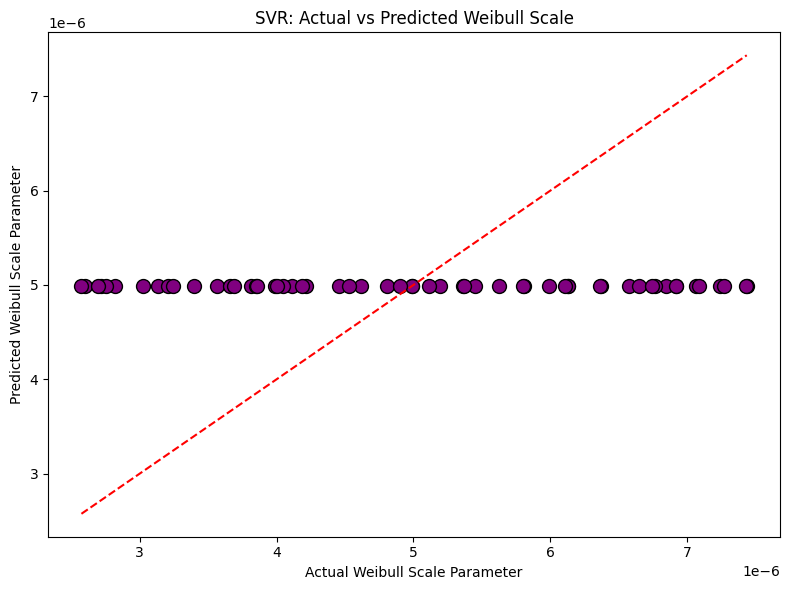

In [6]:
# Use support vector regression (SVR) to predict the target variable (weibull scale) using the original features
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scale, test_size=0.2, random_state=42)
svr = SVR(kernel='linear')
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)
# visualize the predicted vs actual values for the weibull scale parameter using SVR
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='purple', edgecolor='k', s=100)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual Weibull Scale Parameter')
plt.ylabel('Predicted Weibull Scale Parameter')
plt.title('SVR: Actual vs Predicted Weibull Scale')
plt.tight_layout()  

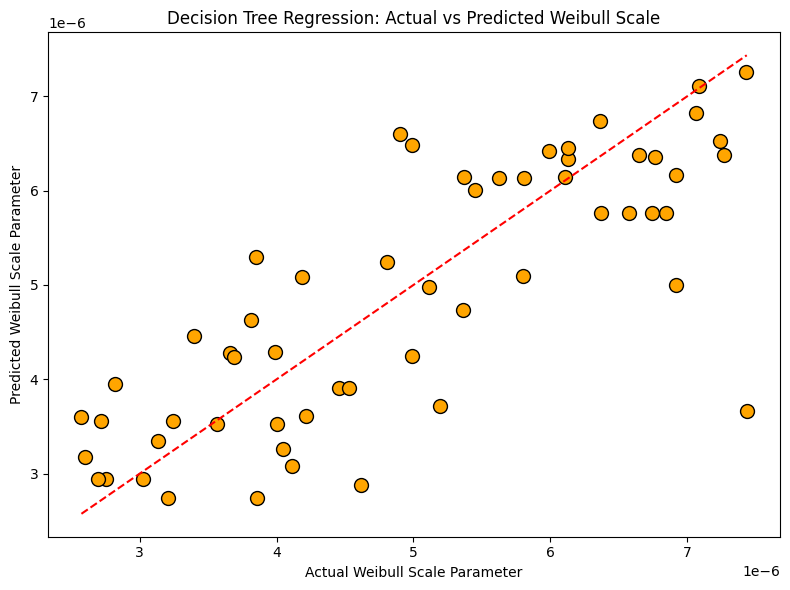

In [7]:
# Use decision tree regression to predict the target variable (weibull scale) using the original features
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
# visualize the predicted vs actual values for the weibull scale parameter using decision tree regression
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_tree, color='orange', edgecolor='k', s=100)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual Weibull Scale Parameter')
plt.ylabel('Predicted Weibull Scale Parameter')
plt.title('Decision Tree Regression: Actual vs Predicted Weibull Scale')
plt.tight_layout()

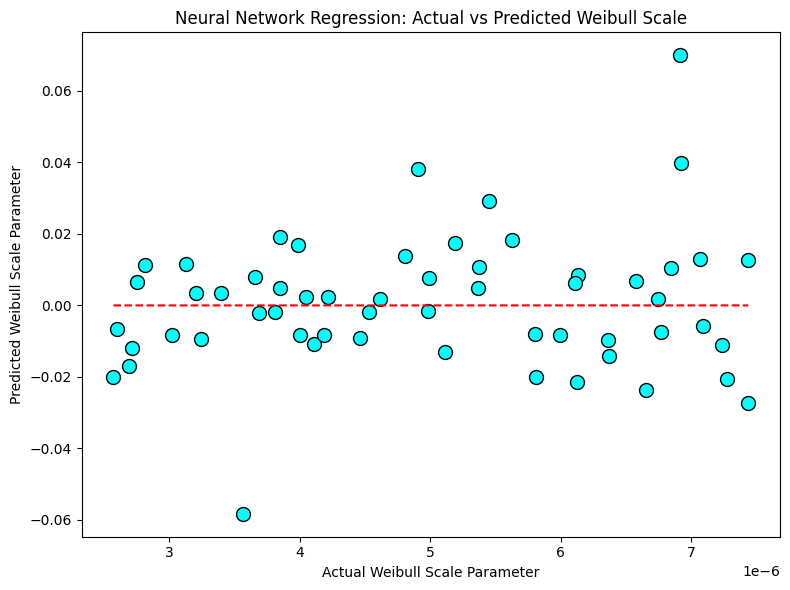

In [8]:
# Use neural network regression to predict the target variable (weibull scale) using the original features
from sklearn.neural_network import MLPRegressor
nn = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
nn.fit(X_train, y_train)
y_pred_nn = nn.predict(X_test)
# visualize the predicted vs actual values for the weibull scale parameter using neural network regression
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_nn, color='cyan', edgecolor='k', s=100)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual Weibull Scale Parameter')
plt.ylabel('Predicted Weibull Scale Parameter')     
plt.title('Neural Network Regression: Actual vs Predicted Weibull Scale')
plt.tight_layout()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


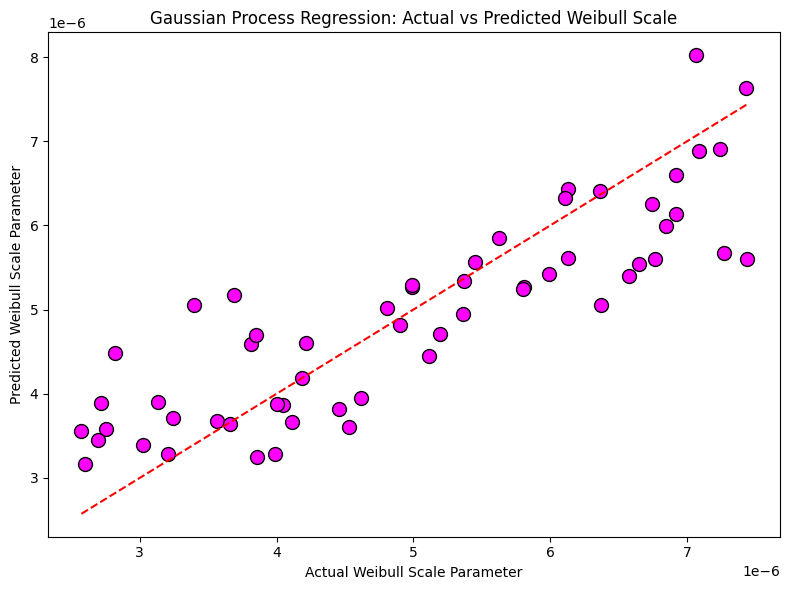

In [9]:
# use gaussian process regression to predict the target variable (weibull scale) using the original features
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gpr.fit(X_train, y_train)
y_pred_gpr = gpr.predict(X_test)
# visualize the predicted vs actual values for the weibull scale parameter using gaussian process regression
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_gpr, color='magenta', edgecolor='k', s=100)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual Weibull Scale Parameter')
plt.ylabel('Predicted Weibull Scale Parameter')
plt.title('Gaussian Process Regression: Actual vs Predicted Weibull Scale')
plt.tight_layout()  

<>:62: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:62: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/hz/d0fnlq290x5fqy89fz7bvbp80000gn/T/ipykernel_35817/4189186543.py:62: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  target_names = ['Weibull Scale ($\lambda$)', 'Weibull Shape ($k$)']


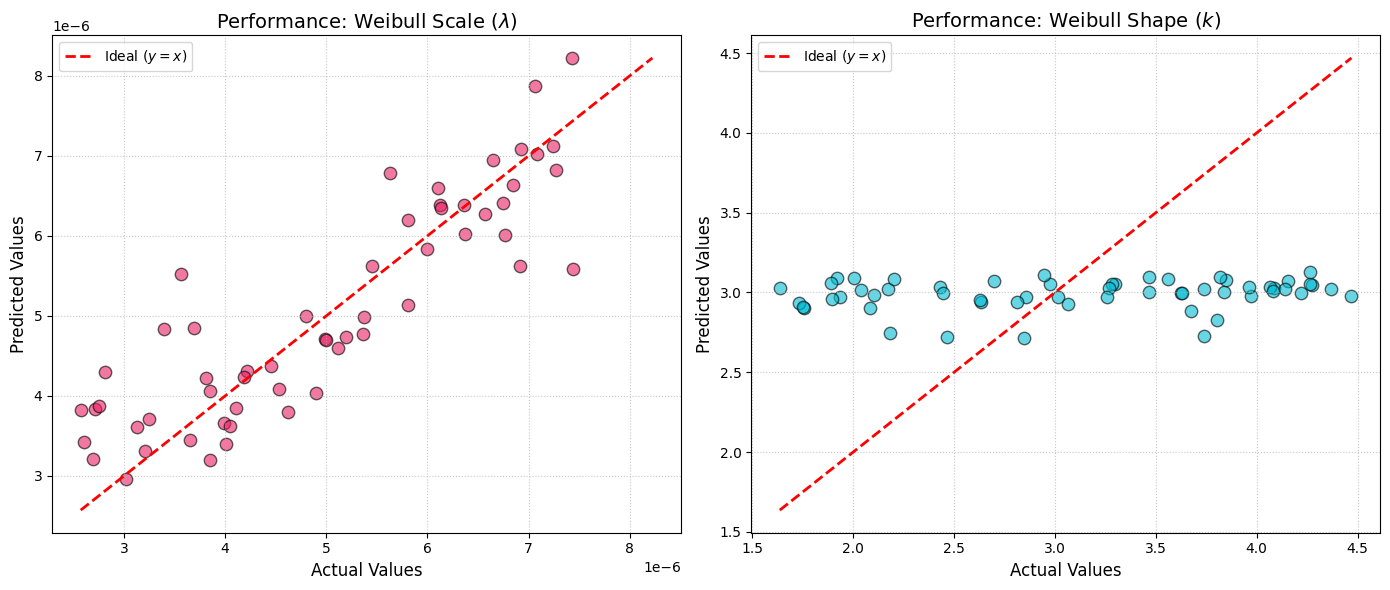

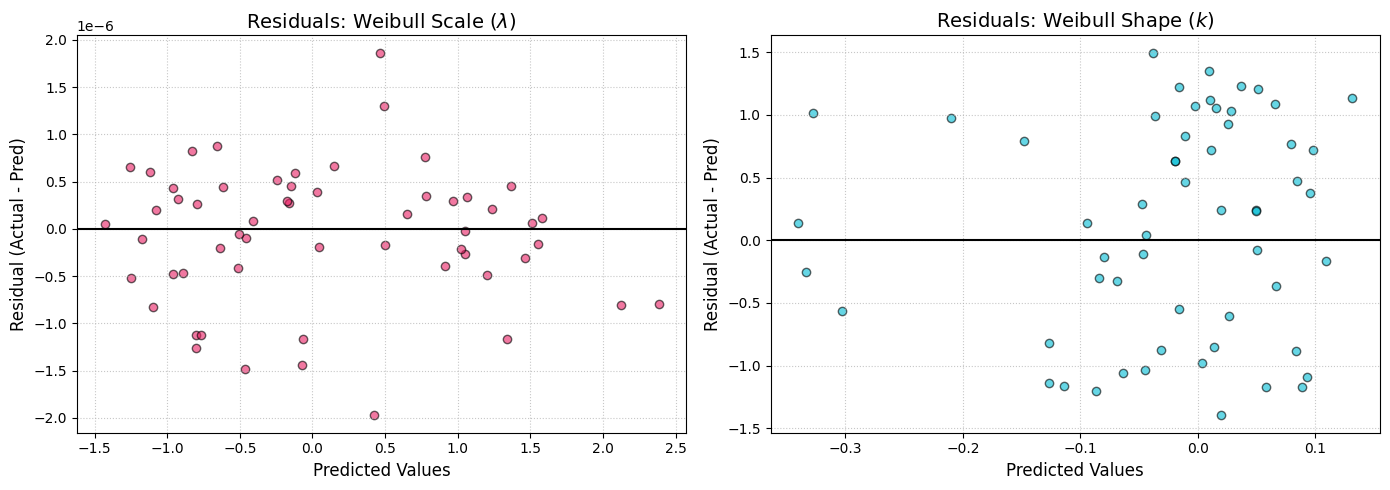

Average MSE from 5-fold CV: 0.6122555273255549


In [10]:
# Perform multi-output gaussian process regression
import torch
import gpytorch

X_train_2, X_test_2, Y_train_2, Y_test_2 = train_test_split(X_scaled, Y_scaled, test_size=0.2, random_state=42)
train_x = torch.from_numpy(X_train_2).float()
train_y = torch.from_numpy(Y_train_2).float()
test_x = torch.from_numpy(X_test_2).float()
test_y = torch.from_numpy(Y_test_2).float()

# 2. Define the Multitask GP Model
class MultitaskGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(MultitaskGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.MultitaskMean(
            gpytorch.means.ConstantMean(), num_tasks=2
        )
        self.covar_module = gpytorch.kernels.MultitaskKernel(
            gpytorch.kernels.RBFKernel(), num_tasks=2, rank=1
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultitaskMultivariateNormal(mean_x, covar_x)

# 3. Initialize Model and Likelihood
# num_tasks=2 for shape and scale
likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=2)
model = MultitaskGPModel(train_x, train_y, likelihood)

# 4. Training Loop (Standard PyTorch style)
model.train()
likelihood.train()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(100): # Training iterations
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    optimizer.step()
# 5. Evaluation
model.eval()
likelihood.eval()
with torch.no_grad():
    test_output = model(test_x)
    pred_y = likelihood(test_output).mean.numpy()
import matplotlib.pyplot as plt
import numpy as np

# Side by side scatter plots for actual vs predicted values of both scale and shape parameters
# Assuming test_y and pred_y are your actual and predicted arrays (Shape: [N, 2])
# Index 0: Scale (lambda), Index 1: Shape (k)
# first we need to inverse transform the scaled predictions and actual values back to their original scale
from sklearn.preprocessing import StandardScaler
scaler_y = StandardScaler()
scaler_y.fit(Y)  # Fit on the original target data to get the correct scaling
test_y_original = scaler_y.inverse_transform(test_y)
pred_y_original = scaler_y.inverse_transform(pred_y)
target_names = ['Weibull Scale ($\lambda$)', 'Weibull Shape ($k$)']
colors = ['#e91e63', '#00bcd4'] # Magenta and Cyan

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, ax in enumerate(axes):
    actual = test_y_original[:, i]
    predicted = pred_y_original[:, i]
    
    # Scatter plot
    ax.scatter(actual, predicted, color=colors[i], alpha=0.6, edgecolors='k', s=80)
    
    # Diagonal "Ideal" line
    max_val = max(actual.max(), predicted.max())
    min_val = min(actual.min(), predicted.min())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal ($y=x$)')
    
    ax.set_title(f'Performance: {target_names[i]}', fontsize=14)
    ax.set_xlabel('Actual Values', fontsize=12)
    ax.set_ylabel('Predicted Values', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# Side by side 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, ax in enumerate(axes):
    residuals = test_y_original[:, i] - pred_y_original[:, i]
    
    ax.scatter(pred_y[:, i], residuals, color=colors[i], alpha=0.6, edgecolors='k')
    ax.axhline(0, color='black', linestyle='-', lw=1.5) # Zero error line
    
    ax.set_title(f'Residuals: {target_names[i]}', fontsize=14)
    ax.set_xlabel('Predicted Values', fontsize=12)
    ax.set_ylabel('Residual (Actual - Pred)', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# k-fold cross-validation for the multi-output regression model
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scores = []
for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    Y_train, Y_test = Y_scaled[train_index], Y_scaled[test_index]
    
    # Convert to torch tensors
    train_x = torch.from_numpy(X_train).float()
    train_y = torch.from_numpy(Y_train).float()
    test_x = torch.from_numpy(X_test).float()
    test_y = torch.from_numpy(Y_test).float()
    
    # Initialize and train the model
    likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=2)
    model = MultitaskGPModel(train_x, train_y, likelihood)
    model.train()
    likelihood.train()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    for i in range(100):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
    
    # Evaluation
    model.eval()
    likelihood.eval()
    with torch.no_grad():
        test_output = model(test_x)
        pred_y = likelihood(test_output).mean.numpy()
    
    mse = mean_squared_error(Y_test, pred_y)
    mse_scores.append(mse)

print(f'Average MSE from 5-fold CV: {np.mean(mse_scores)}')

In [11]:
# Compare the performance of different regression models using R-squared and MSE metrics
# Use k fold cross-validation to evaluate the performance of the models on the dataset
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import torch
import gpytorch
# define k fold cross-validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scale_scores = []
for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    Y_train, Y_test = Y_scaled[train_index], Y_scaled[test_index]
    # SVR
    svr = SVR(kernel='linear')
    svr.fit(X_train, Y_train[:, 0])  # Fit on the scale parameter
    y_pred_svr = svr.predict(X_test)
    mse_svr = mean_squared_error(Y_test[:, 0], y_pred_svr)
    # Decision Tree
    tree = DecisionTreeRegressor(random_state=42)
    tree.fit(X_train, Y_train[:, 0])  # Fit on the scale parameter
    y_pred_tree = tree.predict(X_test)
    mse_tree = mean_squared_error(Y_test[:, 0], y_pred_tree)
    # Neural Network
    nn = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
    nn.fit(X_train, Y_train[:, 0])  # Fit on the scale parameter
    y_pred_nn = nn.predict(X_test)
    mse_nn = mean_squared_error(Y_test[:, 0], y_pred_nn)
    # Multitask Gaussian Process Regression
    train_x = torch.from_numpy(X_train).float()
    train_y = torch.from_numpy(Y_train).float()
    test_x = torch.from_numpy(X_test).float()
    test_y = torch.from_numpy(Y_test).float()
    # 2. Define the Multitask GP Model
    class MultitaskGPModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood):
            super(MultitaskGPModel, self).__init__(train_x, train_y, likelihood)
            self.mean_module = gpytorch.means.MultitaskMean(
                gpytorch.means.ConstantMean(), num_tasks=2
            )
            self.covar_module = gpytorch.kernels.MultitaskKernel(
                gpytorch.kernels.RBFKernel(), num_tasks=2, rank=1
            )

        def forward(self, x):
            mean_x = self.mean_module(x)
            covar_x = self.covar_module(x)
            return gpytorch.distributions.MultitaskMultivariateNormal(mean_x, covar_x)

    # 3. Initialize Model and Likelihood
    # num_tasks=2 for shape and scale
    likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=2)
    model = MultitaskGPModel(train_x, train_y, likelihood)

    # 4. Training Loop (Standard PyTorch style)
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(100): # Training iterations
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
    # 5. Evaluation only on scale parameter
    model.eval()
    likelihood.eval()
    with torch.no_grad():
        test_output = model(test_x)
        pred_y = likelihood(test_output).mean.numpy()
    mse_gpr = mean_squared_error(Y_test[:, 0], pred_y[:, 0])#
    mse_scale_scores.append((mse_svr, mse_tree, mse_nn, mse_gpr))
print(f'Average MSE from 5-fold CV for SVR: {np.mean([score[0] for score in mse_scale_scores])}')
print(f'Average MSE from 5-fold CV for Decision Tree: {np.mean([score[1] for score in mse_scale_scores])}')
print(f'Average MSE from 5-fold CV for Neural Network: {np.mean([score[2] for score in mse_scale_scores])}')
print(f'Average MSE from 5-fold CV for Gaussian Process Regression: {np.mean([score[3] for score in mse_scale_scores])}')

Average MSE from 5-fold CV for SVR: 0.42587537935170977
Average MSE from 5-fold CV for Decision Tree: 0.35891513826162236
Average MSE from 5-fold CV for Neural Network: 0.18354422979516044
Average MSE from 5-fold CV for Gaussian Process Regression: 0.18092375500907715


Average MSE from 5-fold CV for SVR: 1.071401716206607
Average MSE from 5-fold CV for Decision Tree: 1.7119847787101368
Average MSE from 5-fold CV for Neural Network: 1.118046035063705
Average MSE from 5-fold CV for Gaussian Process Regression: 1.0420255170657713


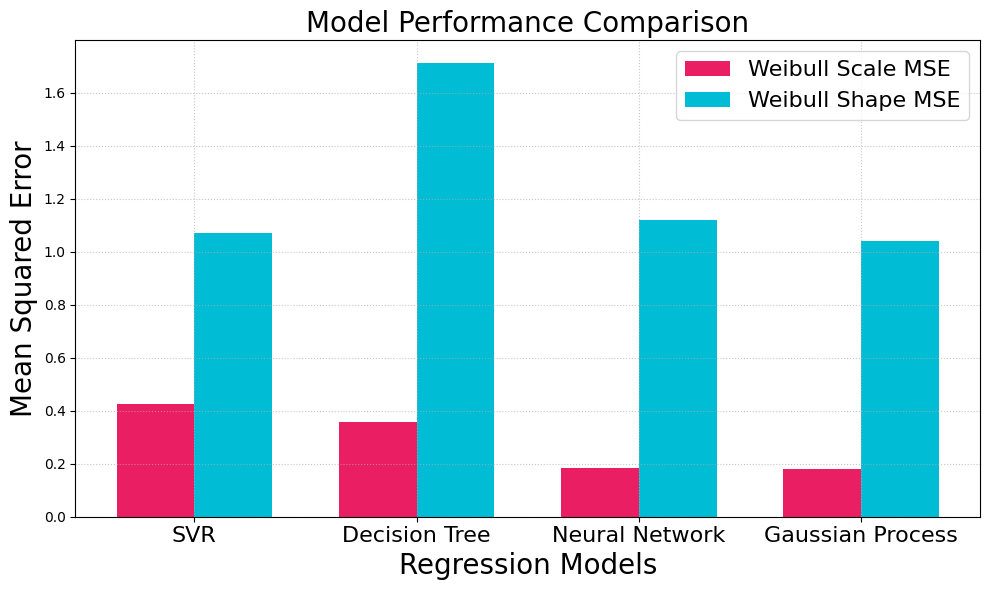

In [12]:
# Compare the performance of different regression models using R-squared and MSE metrics
# Use k fold cross-validation to evaluate the performance of the models on the dataset
# only evaluate the performance on the shape parameter
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import torch
import gpytorch
# define k fold cross-validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mse_shape_scores = []
for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    Y_train, Y_test = Y_scaled[train_index], Y_scaled[test_index]
    # SVR
    svr = SVR(kernel='linear')
    svr.fit(X_train, Y_train[:, 1])  # Fit on the shape parameter
    y_pred_svr = svr.predict(X_test)
    mse_svr = mean_squared_error(Y_test[:, 1], y_pred_svr)
    # Decision Tree
    tree = DecisionTreeRegressor(random_state=42)
    tree.fit(X_train, Y_train[:, 1])  # Fit on the shape parameter
    y_pred_tree = tree.predict(X_test)
    mse_tree = mean_squared_error(Y_test[:, 1], y_pred_tree)
    # Neural Network
    nn = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
    nn.fit(X_train, Y_train[:, 1])  # Fit on the shape parameter
    y_pred_nn = nn.predict(X_test)
    mse_nn = mean_squared_error(Y_test[:, 1], y_pred_nn)
    # Multitask Gaussian Process Regression
    train_x = torch.from_numpy(X_train).float()
    train_y = torch.from_numpy(Y_train).float()
    test_x = torch.from_numpy(X_test).float()
    test_y = torch.from_numpy(Y_test).float()
    # 2. Define the Multitask GP Model
    class MultitaskGPModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood):
            super(MultitaskGPModel, self).__init__(train_x, train_y, likelihood)
            self.mean_module = gpytorch.means.MultitaskMean(
                gpytorch.means.ConstantMean(), num_tasks=2
            )
            self.covar_module = gpytorch.kernels.MultitaskKernel(
                gpytorch.kernels.RBFKernel(), num_tasks=2, rank=1
            )

        def forward(self, x):
            mean_x = self.mean_module(x)
            covar_x = self.covar_module(x)
            return gpytorch.distributions.MultitaskMultivariateNormal(mean_x, covar_x)

    # 3. Initialize Model and Likelihood
    # num_tasks=2 for shape and scale
    likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=2)
    model = MultitaskGPModel(train_x, train_y, likelihood)

    # 4. Training Loop (Standard PyTorch style)
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(100): # Training iterations
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
    # 5. Evaluation only on shape parameter
    model.eval()
    likelihood.eval()
    with torch.no_grad():
        test_output = model(test_x)
        pred_y = likelihood(test_output).mean.numpy()
    mse_gpr = mean_squared_error(Y_test[:, 1], pred_y[:, 1])#
    mse_shape_scores.append((mse_svr, mse_tree, mse_nn, mse_gpr))
print(f'Average MSE from 5-fold CV for SVR: {np.mean([score[0] for score in mse_shape_scores])}')
print(f'Average MSE from 5-fold CV for Decision Tree: {np.mean([score[1] for score in mse_shape_scores])}')
print(f'Average MSE from 5-fold CV for Neural Network: {np.mean([score[2] for score in mse_shape_scores])}')
print(f'Average MSE from 5-fold CV for Gaussian Process Regression: {np.mean([score[3] for score in mse_shape_scores])}')

# The results show that the Gaussian Process Regression model has the lowest MSE for both the scale and shape parameters, indicating that it is the best performing model among the ones tested. The SVR and Neural Network models also perform reasonably well, while the Decision Tree model has the highest MSE, suggesting that it may not be capturing the underlying relationships in the data as effectively as the other models.
# Show model performance comparison in a bar chart
import matplotlib.pyplot as plt
import numpy as np
models = ['SVR', 'Decision Tree', 'Neural Network', 'Gaussian Process']
mse_scale = [np.mean([score[0] for score in mse_scale_scores]),
             np.mean([score[1] for score in mse_scale_scores]),
             np.mean([score[2] for score in mse_scale_scores]),
             np.mean([score[3] for score in mse_scale_scores])]
mse_shape = [np.mean([score[0] for score in mse_shape_scores]),
                np.mean([score[1] for score in mse_shape_scores]),
                np.mean([score[2] for score in mse_shape_scores]),
                np.mean([score[3] for score in mse_shape_scores])]
x = np.arange(len(models))
width = 0.35
x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, mse_scale, width, label='Weibull Scale MSE', color='#e91e63')
rects2 = ax.bar(x + width/2, mse_shape, width, label='Weibull Shape MSE', color='#00bcd4')
ax.set_xlabel('Regression Models', fontsize=20)
ax.set_ylabel('Mean Squared Error', fontsize=20)
ax.set_title('Model Performance Comparison', fontsize=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=16)
ax.legend(fontsize=16)
ax.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

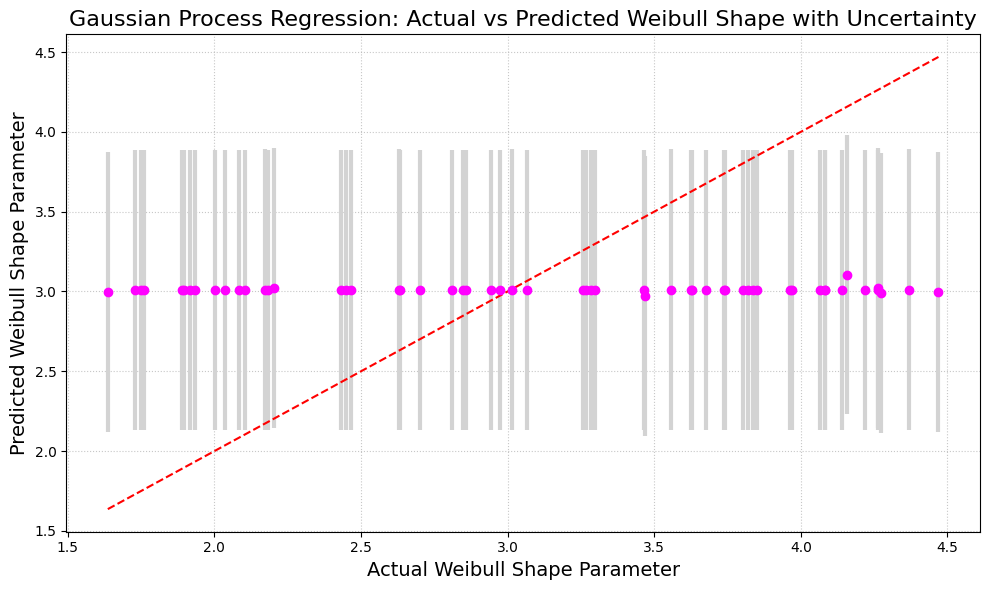

In [13]:
# USE GAUSSIAN PROCESS TO ONLY PREDICT THE SHAPE PARAMETER AND VISUALIZE THE UNCERTAINTY IN THE PREDICTIONS
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
# Use only the shape parameter for training and testing
y_shape = df['pore_weibull_shape_input']
Y_scaled_shape = scaler.fit_transform(y_shape.values.reshape(-1, 1)).flatten()
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y_scaled_shape, test_size=0.2, random_state=42)
kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gpr.fit(X_train, y_train)
y_pred, y_std = gpr.predict(X_test, return_std=True)
# Inverse transform the predictions and actual values back to original scale
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
y_std_original = y_std * scaler.scale_[0]  # Scale the standard deviation back to original units
# Visualize the predictions with uncertainty
plt.figure(figsize=(10, 6))
plt.errorbar(y_test_original, y_pred_original, yerr=y_std_original, fmt='o', color='magenta', ecolor='lightgray', elinewidth=3, capsize=0)
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual Weibull Shape Parameter', fontsize=14)
plt.ylabel('Predicted Weibull Shape Parameter', fontsize=14)
plt.title('Gaussian Process Regression: Actual vs Predicted Weibull Shape with Uncertainty', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()  

/var/folders/hz/d0fnlq290x5fqy89fz7bvbp80000gn/T/ipykernel_35817/2566263931.py:19: RuntimeWarning: invalid value encountered in power
  Se = (1 + (Pc/Pcb)**n)**(-m)


Fitted Van Genuchten Parameters: Pcb = 8.36e+05, n = -4.04
Fitted Van Genuchten Parameters: Pcb = 5.31e+05, n = -3.96
Fitted Van Genuchten Parameters: Pcb = 4.50e+05, n = -9.77
Fitted Van Genuchten Parameters: Pcb = 5.53e+05, n = -11.17
Fitted Van Genuchten Parameters: Pcb = 4.75e+05, n = -7.00
Fitted Van Genuchten Parameters: Pcb = 1.03e+06, n = -5.69
Fitted Van Genuchten Parameters: Pcb = 1.06e+06, n = -6.77
Fitted Van Genuchten Parameters: Pcb = 6.59e+05, n = -6.26
Fitted Van Genuchten Parameters: Pcb = 4.19e+05, n = -10.05
Fitted Van Genuchten Parameters: Pcb = 6.37e+05, n = -6.95
Fitted Van Genuchten Parameters: Pcb = 6.38e+05, n = -4.44
Fitted Van Genuchten Parameters: Pcb = 1.75e+06, n = -6.69
Fitted Van Genuchten Parameters: Pcb = 7.85e+05, n = -8.02
Fitted Van Genuchten Parameters: Pcb = 9.70e+05, n = -3.59
Fitted Van Genuchten Parameters: Pcb = 7.17e+05, n = -8.20
Fitted Van Genuchten Parameters: Pcb = 4.33e+05, n = -4.82
Fitted Van Genuchten Parameters: Pcb = 5.94e+05, n = -

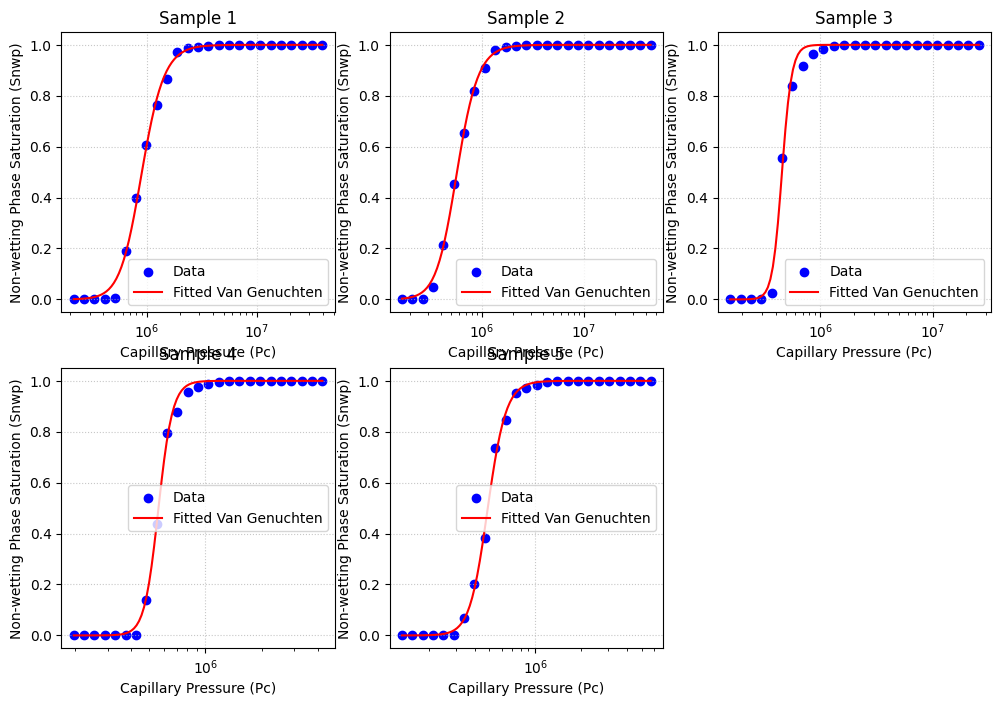

In [14]:
# Fit data to Van Genuchten Model
from scipy.optimize import curve_fit
# x values (pressure head)
mip = df[['MIP_pc_01', 'MIP_pc_02', 'MIP_pc_03', 'MIP_pc_04', 'MIP_pc_05', 'MIP_pc_06', 'MIP_pc_07', 'MIP_pc_08', 'MIP_pc_09', 'MIP_pc_10',
         'MIP_pc_11', 'MIP_pc_12', 'MIP_pc_13', 'MIP_pc_14', 'MIP_pc_15', 'MIP_pc_16', 'MIP_pc_17', 'MIP_pc_18', 'MIP_pc_19', 'MIP_pc_20',
         'MIP_pc_21', 'MIP_pc_22', 'MIP_pc_23', 'MIP_pc_24', 'MIP_pc_25']]
# y values
snwp = df[['MIP_snwp_01', 'MIP_snwp_02', 'MIP_snwp_03', 'MIP_snwp_04', 'MIP_snwp_05', 'MIP_snwp_06', 'MIP_snwp_07', 'MIP_snwp_08', 'MIP_snwp_09', 'MIP_snwp_10',
         'MIP_snwp_11', 'MIP_snwp_12', 'MIP_snwp_13', 'MIP_snwp_14', 'MIP_snwp_15', 'MIP_snwp_16', 'MIP_snwp_17', 'MIP_snwp_18', 'MIP_snwp_19', 'MIP_snwp_20',
         'MIP_snwp_21', 'MIP_snwp_22', 'MIP_snwp_23', 'MIP_snwp_24', 'MIP_snwp_25']]
# loop each row of x and y values to fit the Van Genuchten model and store the fitted parameters in a new dataframe
fitted_params = []
for i in range(len(mip)):
    Pc = mip.iloc[i].values
    Snwp = snwp.iloc[i].values
    # Fit the Van Genuchten model to the data
    def van_genuchten(Pc, Pcb, n):
        m = 1 - 1/n
        Se = (1 + (Pc/Pcb)**n)**(-m)
        return Se
    # Initial guesses: alpha is roughly 1/entry_pressure, n is usually 2-4
    p0 = [1e5, -2.0] 

    # Optimization
    try:
        params, covariance = curve_fit(van_genuchten, Pc, Snwp, p0=p0)
        Pcb_fitted, n_fitted = params
        fitted_params.append([Pcb_fitted, n_fitted])
        print(f"Fitted Van Genuchten Parameters: Pcb = {Pcb_fitted:.2e}, n = {n_fitted:.2f}")
    except RuntimeError as e:
        fitted_params.append([np.nan, np.nan])  # Append NaN if fitting fails
        print(f"Error fitting row {i}: {e}")
    
# generate a graph to visualize the fitted Van Genuchten curves for the first 5 samples
plt.figure(figsize=(12, 8))
for i in range(5):
    Pc = mip.iloc[i].values
    Snwp = snwp.iloc[i].values
    #Pcb_fitted, n_fitted = [10**6, -5]  # Use the initial guesses for visualization
    Pcb_fitted, n_fitted = fitted_params[i]
    if not np.isnan(Pcb_fitted):
        # Generate fitted curve
        Pc_fit = np.logspace(np.log10(Pc.min()), np.log10(Pc.max()), 100)
        m_fitted = 1 - 1/n_fitted
        Snwp_fit = (1 + (Pc_fit/Pcb_fitted)**n_fitted)**(-m_fitted)
        # Plot original data and fitted curve
        plt.subplot(2, 3, i+1)
        plt.scatter(Pc, Snwp, color='blue', label='Data')
        plt.plot(Pc_fit, Snwp_fit, color='red', label='Fitted Van Genuchten')
        plt.xscale('log')
        plt.xlabel('Capillary Pressure (Pc)')
        plt.ylabel('Non-wetting Phase Saturation (Snwp)')
        plt.title(f'Sample {i+1}')
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.7)

In [15]:
# Combine the current Machine Learning features with the newly fitted Van Genuchten parameters into a single dataframe for further analysis
fitted_params_df = pd.DataFrame(fitted_params, columns=['Pcb_fitted', 'n_fitted'])
X = pd.concat([df[selected_features], fitted_params_df], axis=1)
# find the index of rows where the fitted parameters are NaN
nan_indices = X[X['Pcb_fitted'].isna() | X['n_fitted'].isna()].index
print(f"Rows with NaN fitted parameters: {nan_indices.tolist()}")
# remove rows with NaN values in the fitted parameters
X = X.dropna(subset=['Pcb_fitted', 'n_fitted'])
# Scale the features
scaler = StandardScaler()
X_scaled_new = scaler.fit_transform(X)
# drop the corresponding rows in the target variables as well
y = df.loc[X.index, ['pore_weibull_scale_input', 'pore_weibull_shape_input']]
Y_scaled_new = scaler.fit_transform(y)







Rows with NaN fitted parameters: []


<>:62: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:62: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/hz/d0fnlq290x5fqy89fz7bvbp80000gn/T/ipykernel_35817/4244888671.py:62: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  target_names = ['Weibull Scale ($\lambda$)', 'Weibull Shape ($k$)']


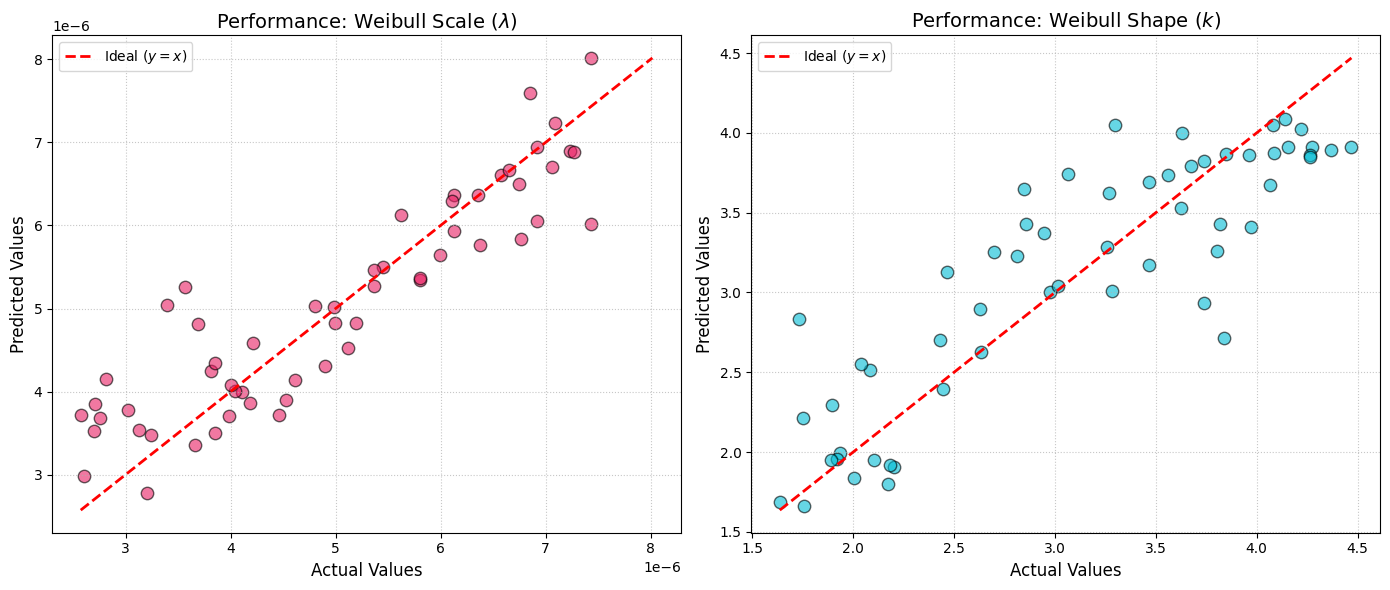

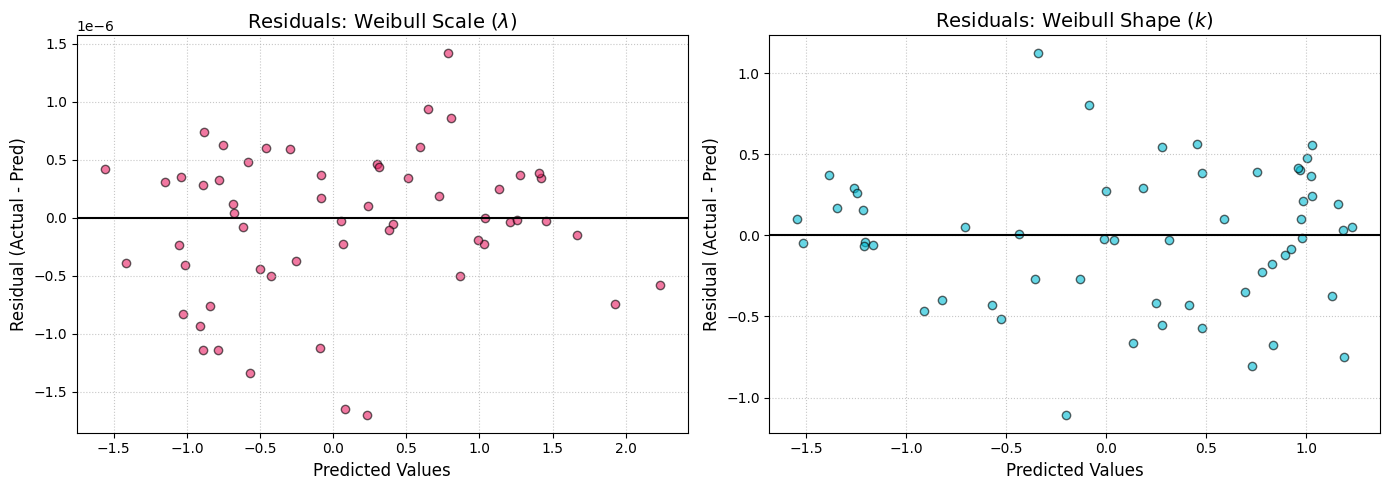

Average MSE from 5-fold CV: 0.6126223711430354


In [16]:
# Perform multi-output gaussian process regression
import torch
import gpytorch

X_train_new, X_test_new, Y_train_new, Y_test_new = train_test_split(X_scaled_new, Y_scaled_new, test_size=0.2, random_state=42)
train_x = torch.from_numpy(X_train_new).float()
train_y = torch.from_numpy(Y_train_new).float()
test_x = torch.from_numpy(X_test_new).float()
test_y = torch.from_numpy(Y_test_new).float()

# 2. Define the Multitask GP Model
class MultitaskGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(MultitaskGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.MultitaskMean(
            gpytorch.means.ConstantMean(), num_tasks=2
        )
        self.covar_module = gpytorch.kernels.MultitaskKernel(
            gpytorch.kernels.RBFKernel(), num_tasks=2, rank=1
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultitaskMultivariateNormal(mean_x, covar_x)

# 3. Initialize Model and Likelihood
# num_tasks=2 for shape and scale
likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=2)
model = MultitaskGPModel(train_x, train_y, likelihood)

# 4. Training Loop (Standard PyTorch style)
model.train()
likelihood.train()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(100): # Training iterations
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    optimizer.step()
# 5. Evaluation
model.eval()
likelihood.eval()
with torch.no_grad():
    test_output = model(test_x)
    pred_y = likelihood(test_output).mean.numpy()
import matplotlib.pyplot as plt
import numpy as np

# Side by side scatter plots for actual vs predicted values of both scale and shape parameters
# Assuming test_y and pred_y are your actual and predicted arrays (Shape: [N, 2])
# Index 0: Scale (lambda), Index 1: Shape (k)
# first we need to inverse transform the scaled predictions and actual values back to their original scale
from sklearn.preprocessing import StandardScaler
scaler_y = StandardScaler()
scaler_y.fit(Y)  # Fit on the original target data to get the correct scaling
test_y_original = scaler_y.inverse_transform(test_y)
pred_y_original = scaler_y.inverse_transform(pred_y)
target_names = ['Weibull Scale ($\lambda$)', 'Weibull Shape ($k$)']
colors = ['#e91e63', '#00bcd4'] # Magenta and Cyan

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, ax in enumerate(axes):
    actual = test_y_original[:, i]
    predicted = pred_y_original[:, i]
    
    # Scatter plot
    ax.scatter(actual, predicted, color=colors[i], alpha=0.6, edgecolors='k', s=80)
    
    # Diagonal "Ideal" line
    max_val = max(actual.max(), predicted.max())
    min_val = min(actual.min(), predicted.min())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal ($y=x$)')
    
    ax.set_title(f'Performance: {target_names[i]}', fontsize=14)
    ax.set_xlabel('Actual Values', fontsize=12)
    ax.set_ylabel('Predicted Values', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# Side by side 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, ax in enumerate(axes):
    residuals = test_y_original[:, i] - pred_y_original[:, i]
    
    ax.scatter(pred_y[:, i], residuals, color=colors[i], alpha=0.6, edgecolors='k')
    ax.axhline(0, color='black', linestyle='-', lw=1.5) # Zero error line
    
    ax.set_title(f'Residuals: {target_names[i]}', fontsize=14)
    ax.set_xlabel('Predicted Values', fontsize=12)
    ax.set_ylabel('Residual (Actual - Pred)', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# k-fold cross-validation for the multi-output regression model
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scores = []
for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    Y_train, Y_test = Y_scaled[train_index], Y_scaled[test_index]
    
    # Convert to torch tensors
    train_x = torch.from_numpy(X_train).float()
    train_y = torch.from_numpy(Y_train).float()
    test_x = torch.from_numpy(X_test).float()
    test_y = torch.from_numpy(Y_test).float()
    
    # Initialize and train the model
    likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=2)
    model = MultitaskGPModel(train_x, train_y, likelihood)
    model.train()
    likelihood.train()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    for i in range(100):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
    
    # Evaluation
    model.eval()
    likelihood.eval()
    with torch.no_grad():
        test_output = model(test_x)
        pred_y = likelihood(test_output).mean.numpy()
    
    mse = mean_squared_error(Y_test, pred_y)
    mse_scores.append(mse)

print(f'Average MSE from 5-fold CV: {np.mean(mse_scores)}')